# Contributions, using MMA

Inspiration for these plots and analysis follows from {cite:t}`marra_advancing_2023` and {cite:t}`sweet_implications_2024`, which use the nonstationary GEV analysis of {cite:t}`mendez_analyzing_2007` to analyze the influence of climatic patterns like ENSO and PDO (for example) on extreme sea levels. This notebook instead uses a monthly mean anomaly as the covariate. 

## Setup

First we'll import the necessary functions, set up our directories, and get everything ready for plotting.

In [1]:
%run setup.ipynb
%run plotting_functions.ipynb
import json
from scipy.stats import chi2
import sys
cwd = os.getcwd()
base_dir = os.path.abspath(os.path.join(cwd, "../"))  # For interactive mode (Jupyter/IPython)
pythonPath = os.path.join(base_dir, 'python', 'nonstationaryGEV')
sys.path.append(pythonPath)
sys.path.append(os.path.join(base_dir, 'python'))

from imports import make_directoryDict
from helpers import adjust_w_for_plotting
from maps import plot_thin_map_hawaii, get_stationinfo


# set up directories to read from
dirs = make_directoryDict(base_dir)

from matplotlib import colors, cm
from matplotlib.lines import Line2D


# Calculate the Monthly Mean Anomaly

To get this, we'll follow these steps:
1) Calculate the monthly mean time series (here, calculated from daily means).
2) Remove the trend from the time series (detrend)
3) Remove the seasonality (de-season)
4) Normalize, such that the mean is 0 and the standard deviation is 1. (i.e. we are looking at the relative strength of the anomaly, not the absolute magnitude.)

In [2]:
rsl_daily = xr.open_dataset(data_dir/ 'rsl_daily_hawaii.nc')
data_coverage = rsl_daily.rsl_mhhw.count(dim='time')/len(rsl_daily.time)

#drop all locations with data_coverage less than 80%
rsl_subset = rsl_daily.where(data_coverage>0.80,drop=True)

rsl_subset

<xarray.Dataset> Size: 1MB
Dimensions:       (record_id: 8, time: 11688)
Coordinates:
  * record_id     (record_id) int64 64B 50 52 57 58 59 60 61 552
  * time          (time) datetime64[ns] 94kB 1993-01-01 ... 2024-12-31
    lat           (record_id) float32 32B 28.22 16.75 21.31 ... 21.43 20.03
    lon           (record_id) float32 32B 182.6 190.5 202.1 ... 202.2 204.2
    station_name  (record_id) <U17 544B 'Midway' 'Johnston' ... 'Kawaihae'
    storm_time    (time) datetime64[ns] 94kB ...
Data variables:
    rsl_anomaly   (record_id, time) float32 374kB -0.05425 -0.022 ... -0.03271
    rsl_mhhw      (record_id, time) float64 748kB -0.2078 -0.1756 ... -0.342
Attributes:
    long_name:  Sea Level Anomaly
    units:      m
    source:     in situ tide gauge water level observations
    platform:   station_name, station_country, station_country_code, uhslc_id...
    epoch:      1993-2001

## 1) Calculate the monthly mean time series

In [3]:
# Resample the data to get monthly means, using a 3-month rolling mean
# and squeeze to remove the time dimension if it becomes length 1
rsl_monthly = (
    rsl_subset
    .resample(time='MS')
    .mean()
    .rolling(time=3, center=True, min_periods=1)
    .mean()
    .squeeze()
)


## 2) Remove the trend from the time series (detrend)

In [4]:
# remove the trend
from tseries_functions import process_trend_with_nan
trend_mag, sea_level_trend, trend_rate = process_trend_with_nan(rsl_monthly.rsl_anomaly)
# Calculate the monthly mean sea level anomaly
MMA_detrended = rsl_monthly.rsl_anomaly - sea_level_trend

Processing xarray DataArray...
Processing multidimensional xarray DataArray...


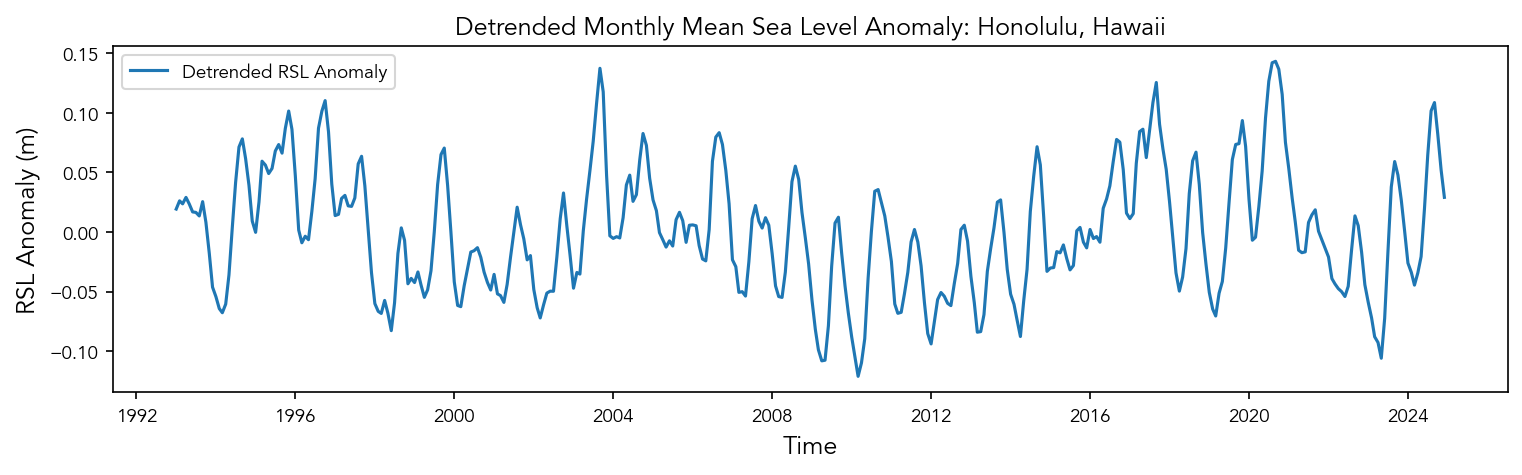

In [5]:
# make figure
plt.figure(figsize=(12, 3))

plt.plot(MMA_detrended.time, MMA_detrended.sel(record_id=57), label='Detrended RSL Anomaly')
plt.xlabel('Time')
plt.ylabel('RSL Anomaly (m)')
plt.title('Detrended Monthly Mean Sea Level Anomaly: ' + str(rsl_monthly.station_name.sel(record_id=57).values))
plt.legend()
plt.show()

## 3) Remove the seasonality (de-season)

In [6]:
# get seasonal cycle by grouping by month and averaging
seasonal_cycle = MMA_detrended.groupby('time.month').mean(dim='time')
# remove mean from seasonal cycle
seasonal_cycle = seasonal_cycle - seasonal_cycle.mean(dim='month')

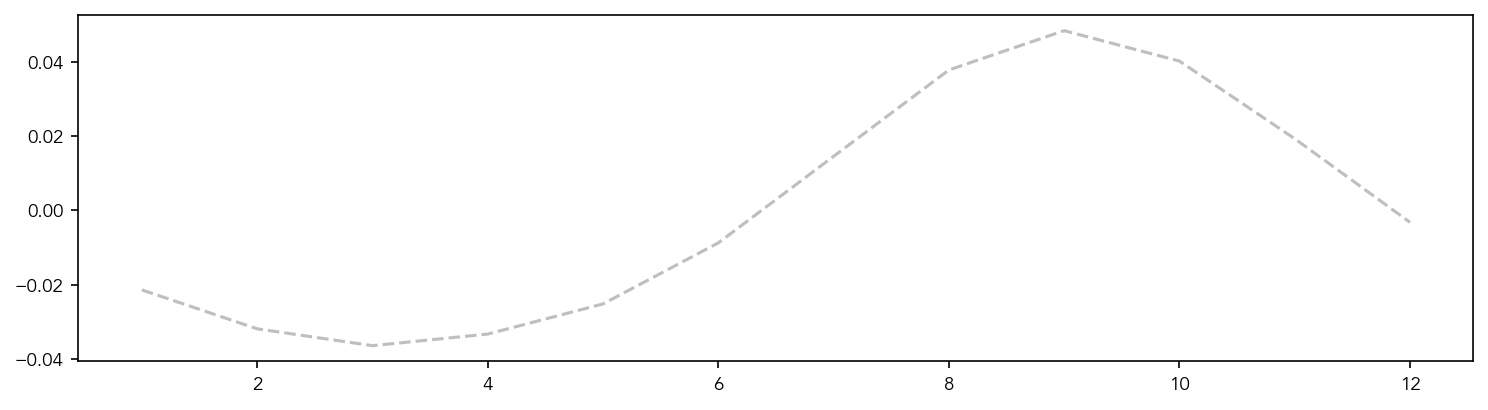

In [7]:
# plot seasonal cycle
plt.figure(figsize=(12, 3))
plt.plot(seasonal_cycle.month, seasonal_cycle.sel(record_id=57), linestyle='--', color='gray', alpha=0.5)

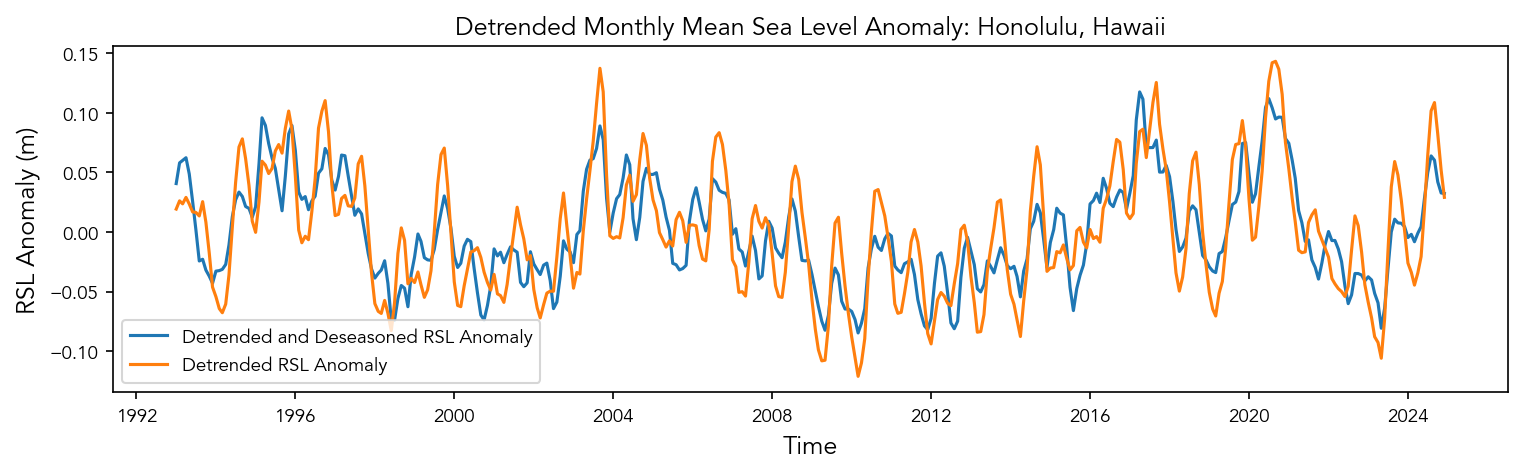

In [8]:
# now remove the seasonal cycle, calculated above as record_mean
MMA_detrended_deseasoned = MMA_detrended.groupby('time.month') - seasonal_cycle

# make figure
plt.figure(figsize=(12, 3))

plt.plot(MMA_detrended_deseasoned.time, MMA_detrended_deseasoned.sel(record_id=57), label='Detrended and Deseasoned RSL Anomaly')
plt.plot(MMA_detrended.time, MMA_detrended.sel(record_id=57), label='Detrended RSL Anomaly')

plt.xlabel('Time')
plt.ylabel('RSL Anomaly (m)')
plt.title('Detrended Monthly Mean Sea Level Anomaly: ' + str(rsl_monthly.station_name.sel(record_id=57).values))
plt.legend()
plt.show()

## 4) Normalize
We'll take this MMA data, normalize it such that the mean is 0 and the standard deviation is 1 (as in the climate indices), and use it in our analysis.

In [9]:
# Turn MMA_detrended_deseasoned into a dataframe, with time as index, and record_id as columns
MMA_df = MMA_detrended_deseasoned.to_dataframe().reset_index().pivot(index='time', columns='record_id', values='rsl_anomaly')

#normalize such that the mean is 0 and std is 1
MMA_df = (MMA_df - MMA_df.mean()) / MMA_df.std()

# Save the dataframe to a CSV file
MMA_df.to_csv(dirs['CI_dir'] / 'MMA.csv')

# Run the Model
This involves running python code with MPI setup, and is probably best done outside the notebook. The code can be found in python/nonstationaryGEV, and you'll want to run main.py. I still need to clean this up a bit but for now we can look at the results.

### Compile data 
Before running this, you will need to run the non-stationary models. In the following codes we are just compiling the output and results from those models that have been saved to "model_output_dir" directory. The methodology contained herein follows {cite:t}`sweet_implications_2024`.

In [10]:
# get list of all directories in dirs['model_output_dir']
dirs_list = os.listdir(dirs['model_output_dir'])

# only keep the directories that are numbers
recordIDs = [int(d) for d in dirs_list if d.isdigit()]


# get station names from the best_params.json files
station_names = {}
for recordID in recordIDs:
    jsonpath = Path(dirs['model_output_dir']) / str(recordID) / 'best_params.json'
    with open(jsonpath, 'r') as f:
        output = json.load(f)
        station_names[recordID] = output['modelInfo']['station_name']

# sort the station names by the recordID
station_names = {k: v for k, v in sorted(station_names.items(), key=lambda item: item[0])}

station_names

{50: 'Midway',
 52: 'Johnston',
 57: 'Honolulu, Hawaii',
 58: 'Nawiliwili',
 59: 'Kahului',
 60: 'Hilo, Hawaii',
 61: 'Mokuoloe',
 552: 'Kawaihae'}

#### Plot all models
Next we'll look at all models and how they compare.

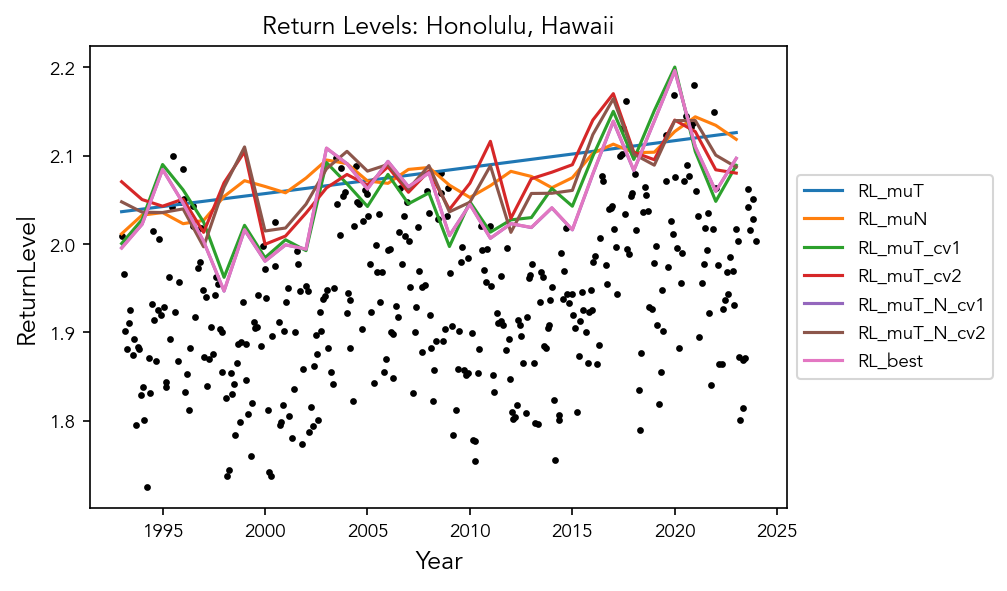

In [11]:
# Only do Honolulu for now
recordID = 57

modelTypes = ['RL_muT', 'RL_muN','RL_muT_cv1','RL_muT_cv2','RL_muT_N_cv1','RL_muT_N_cv2','RL_best']

for modelType in modelTypes:
    modelName = modelType + '.nc'
    modelPath = Path(dirs['model_output_dir'] / str(recordID) / modelName)

    if not modelPath.exists():
        continue
    model = xr.open_dataset(modelPath)

    model['ReturnLevel'].sel(ReturnPeriod=2).plot(label=modelType)

plt.legend()
# put the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# read the json file for best model
jsonpath = Path(dirs['model_output_dir']) / str(recordID) / 'best_params.json'
with open(jsonpath, 'r') as f:
    output = json.load(f)
    modelInfo = output['modelInfo']
    params = output['w']
    x = output['x']

time = modelInfo['year0'] + pd.Series(modelInfo['t'])
plt.scatter(time, modelInfo['monthlyMax'], color='k', label='Monthly Maxima', s=5)

plt.title('Return Levels: ' + model.attrs['station_name'])

w = adjust_w_for_plotting(x, params)

### Plot Components in time
First we'll make a function for plotting.

In [12]:
def plot_location(w, modelInfo, label, offset=0, component=True):
    # Unpack the w array
    b0, b1, b2, b3, b4, b5, b6 = w[0], w[3], w[4], w[5], w[6], w[7], w[8]
    a0, bLT, bCI, aCI, bN1, bN2, bP1, bP2 = w[1], w[9], w[10], w[11], w[12], w[13], w[14], w[15]

    # Check if w[10] (bCI) is zero (i.e., no covariate contribution)
    if bCI == 0:
        ti = np.arange(0, modelInfo['t'][-1], 0.01)
        CI = 0  # Covariate is zero if bCI is zero
    else:
        ti = pd.Series(modelInfo['t']) 
        CI = pd.Series(modelInfo['covariate'])  # Covariate values

        

    # Make sure CI and ti are aligned (if CI is a series)
    if isinstance(CI, pd.Series) and len(CI) != len(ti):
        raise ValueError("Length of covariate CI does not match the length of ti.")

    # Define mut (location(t)) as a function of ti and CI
    mut = (b0 * np.exp(bLT * ti) +
           b1 * np.cos(2 * np.pi * ti) + b2 * np.sin(2 * np.pi * ti) +
           b3 * np.cos(4 * np.pi * ti) + b4 * np.sin(4 * np.pi * ti) +
           b5 * np.cos(8 * np.pi * ti) + b6 * np.sin(8 * np.pi * ti) +
           bN1 * np.cos((2 * np.pi / 18.61) * ti) + bN2 * np.sin((2 * np.pi / 18.61) * ti) +
           bP1 * np.cos((2 * np.pi / 4.425) * ti) + bP2 * np.sin((2 * np.pi / 4.425) * ti) +
           (bCI * CI))  

    # Calculate the amplitudes for each harmonic and the covariate
    amp_annual = np.sqrt(b1**2 + b2**2)      # First harmonic (annual cycle)
    amp_semiannual = np.sqrt(b3**2 + b4**2)  # Second harmonic (semiannual cycle)
    amp_third = np.sqrt(b5**2 + b6**2)       # Third harmonic (quarterly or 8π cycle)
    amp_nodal = np.sqrt(bN1**2 + bN2**2)     # Nodal component
    amp_perigean = np.sqrt(bP1**2 + bP2**2)  # Perigean component
    amp_covariate = abs(bCI)                 # Covariate amplitude
    amp_trend = 0.5*(b0 * np.exp(bLT * modelInfo['t'][-1]) - b0*np.exp(bLT * modelInfo['t'][0]))  # Trend amplitude



    amp_seasonal = np.sqrt(amp_annual**2 + amp_semiannual**2 + amp_third**2)
    
    # Calculate the total amplitude
    amp = np.sqrt(amp_seasonal**2 + amp_nodal**2 + amp_perigean**2 + amp_covariate**2 + amp_trend**2)
    


    # Subtract the datum offset
    mut = mut - modelInfo['STNDtoMHHW']

    if component:
        mut_demeaned = mut - np.mean(mut)
    else:
        mut_demeaned = mut
    
    # mut_demeaned = mut_demeaned - modelInfo['STNDtoMHHW']
    
    # add zero line for reference in gray
    plt.axhline(y=offset, color='gray', linestyle='-.', alpha=0.5)

    # Plot the result

    plt.plot(ti+modelInfo['year0'], mut_demeaned + offset, label=label + ' (' + str(round(2*amp*100, 2)) + ' cm)') 
    return amp



Then we'll make a function for making the figure.

In [13]:
# Make figure
def make_component_figure(w, modelInfo, model, time):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    returnYear = 10

    # Add returnYear-year return level to the plot
    plt.plot(model['Year']+0.5, 
            model['ReturnLevel'].sel(ReturnPeriod=returnYear)-modelInfo['STNDtoMHHW'], 
            label=f'{returnYear}-year Return Level', color='black', linewidth=2) 

    # add error bars as shaded area from model['RL_low'] to model['RL_high']
    plt.fill_between(model['Year']+0.5, 
                    model['RL_high'].sel(ReturnPeriod=returnYear)-modelInfo['STNDtoMHHW'], 
                    model['RL_low'].sel(ReturnPeriod=returnYear)-modelInfo['STNDtoMHHW'],
                    color='gray', alpha=0.2)

    # Add monthly maxima, centered
    mm = np.array(modelInfo['monthlyMax']) - modelInfo['STNDtoMHHW']
    plt.scatter(time, mm, color='gray', label='Monthly Maxima', s=5)
    amp_full = plot_location(w, modelInfo, label='Full $\mu(t)$', offset=0, component=False)

    # First plot: Covariate contribution
    wnew = np.zeros(len(w))
    wnew[10] = w[10]  # Only use the covariate component
    offset1 = -0.2  # Offset for the plot
    amp_CI = plot_location(wnew, modelInfo, label=modelInfo['covariateName'] , offset=offset1)


    # Second plot: Seasonal components
    wnew = np.zeros(len(w))
    wnew[1:9] = w[1:9]  # Seasonal components
    offset1 -= 0.2  # Increment offset correctly
    amp_S = plot_location(wnew, modelInfo, label='Seasonal', offset=offset1)

    # Third plot: Long-term trend
    wnew = np.zeros(len(w))
    wnew[9] = w[9]  # Long-term trend component
    wnew[0] = w[0]  # Plus base value
    offset1 -= 0.2  # Increment offset correctly
    amp_LT = plot_location(wnew, modelInfo, label='Long-term trend', offset=offset1)


    # Fourth plot: Nodal component
    wnew = np.zeros(len(w))
    wnew[12:14] = w[12:14]  # Nodal components
    offset1 -= 0.2  # Increment offset correctly
    amp_N = plot_location(wnew, modelInfo, label='Nodal', offset=offset1)

    # Fourth plot: Nodal component
    wnew = np.zeros(len(w))
    wnew[14:16] = w[14:16]  # Nodal components
    offset1 -= 0.2  # Increment offset correctly
    amp_P = plot_location(wnew, modelInfo, label='Perigean', offset=offset1)

    plt.title('Location Parameter Components: ' + model.attrs['station_name'])
    plt.xlim(modelInfo['t'][0] + modelInfo['year0'], modelInfo['t'][-1] + modelInfo['year0'])
    plt.ylabel('Height above MHHW (m)')

    # Add legend to the outside of the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.subplots_adjust(right=0.85)

    # add a second y-axis on the right side to label components
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(np.arange(0, offset1-0.2, -0.2))
    ax2.set_yticklabels([' Full $\mu(t)$', ' ' +
                      modelInfo['covariateName'] + ' $\mu_{CI}(t)$' , 
                      ' Seasonal $\mu_{S}(t)$', 
                      ' Long-term trend $\mu_{LT}(t)$', 
                      ' Nodal $\mu_{N}(t)$' ,' Perigean $\mu_{P}(t)$']); #not sure why there's output here but I've suppressed it  
    
    amps = [amp_full, amp_CI, amp_S, amp_LT, amp_N, amp_P]
    amp_names = ['Full', 'Covariate', 'Seasonal', 'Long-term trend', 'Nodal', 'Perigean']

        # Get the default color cycle
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
#     x_line_position = ax.get_xlim()[1] + 0.5
    x_line_position = 0.86
    y_ticks = ax2.get_yticks()
    # Draw vertical lines on the figure using figure-relative coordinates
    for i, amp in enumerate(amps):
        ymin_fig = ax2.transData.transform((0, y_ticks[i] - amp))[1]  # Bottom of the line
        ymax_fig = ax2.transData.transform((0, y_ticks[i] + amp))[1]  # Top of the line
        ymin_norm = fig.transFigure.inverted().transform((0, ymin_fig))[1]  # Convert to figure normalized
        ymax_norm = fig.transFigure.inverted().transform((0, ymax_fig))[1]  # Convert to figure normalized
        
        # Plot vertical line in figure coordinates
        fig.lines.append(plt.Line2D([x_line_position, x_line_position], [ymin_norm, ymax_norm],
                                    transform=fig.transFigure, solid_capstyle='round',
                                    color = color_cycle[i],linestyle='-', linewidth=3))


    amps = dict(zip(amp_names, amps))
    return fig, amps, ax


Finally, we'll plot it up!

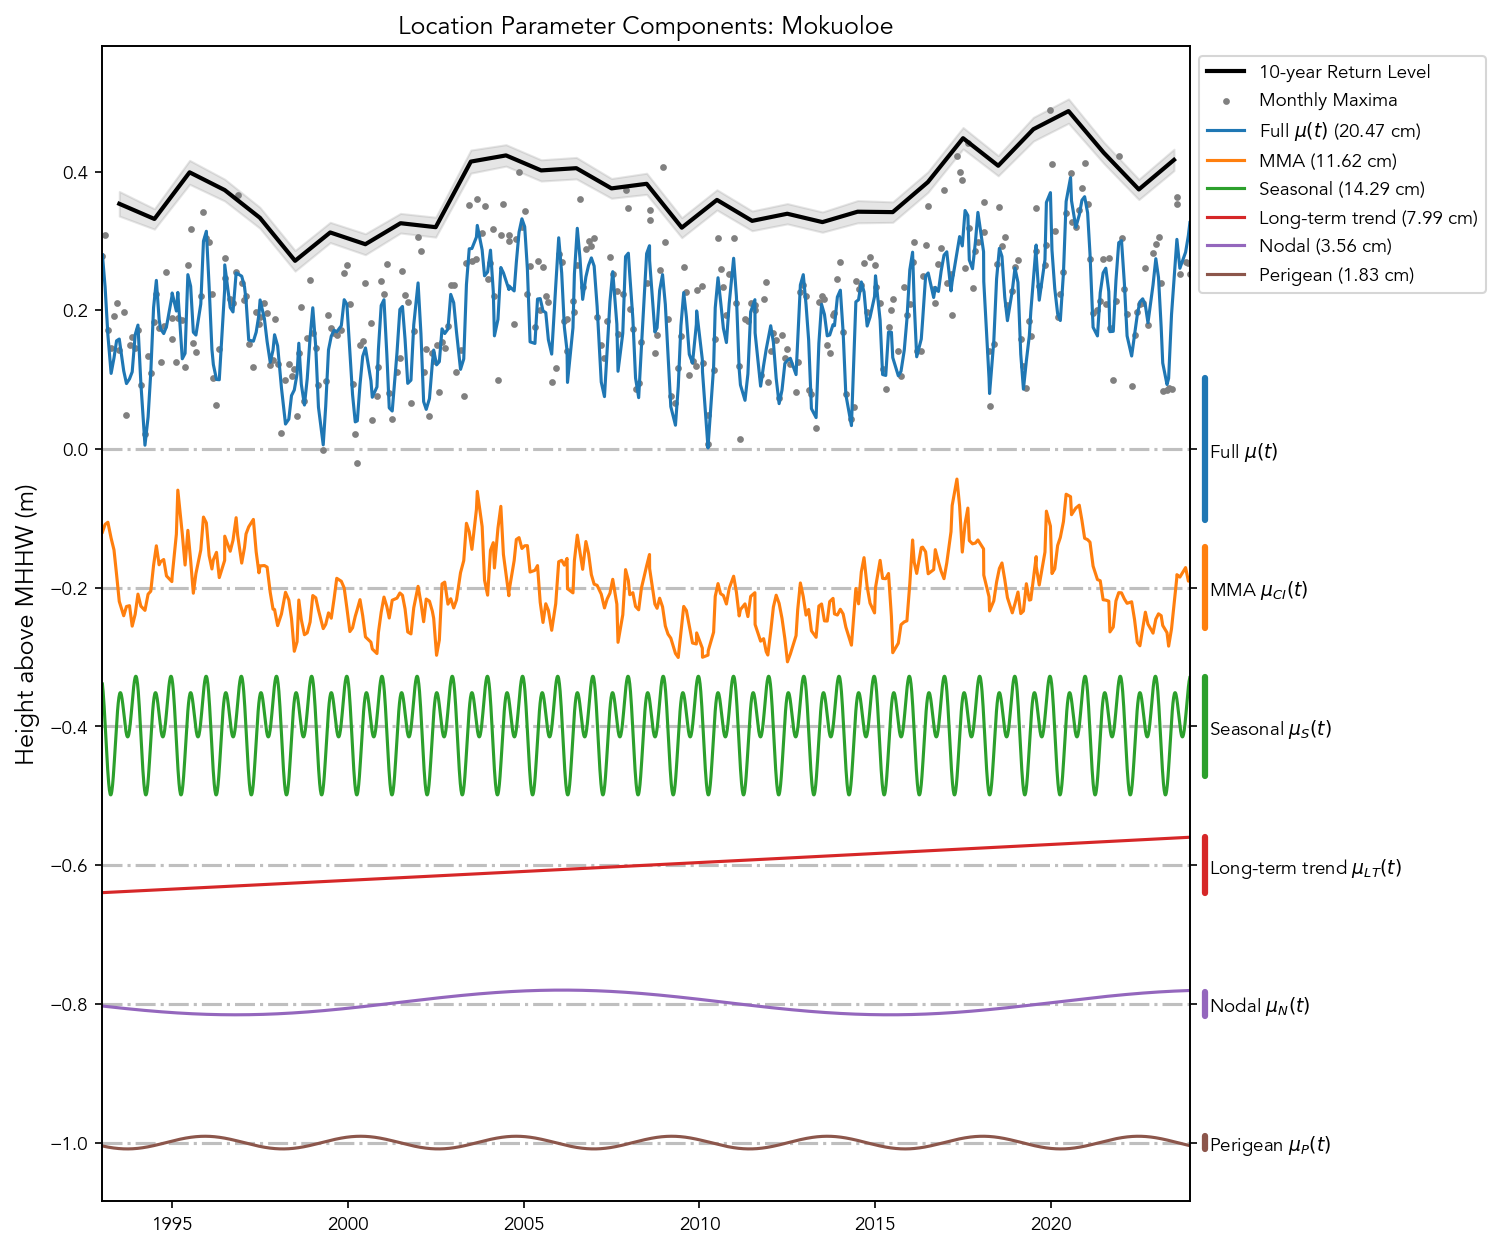

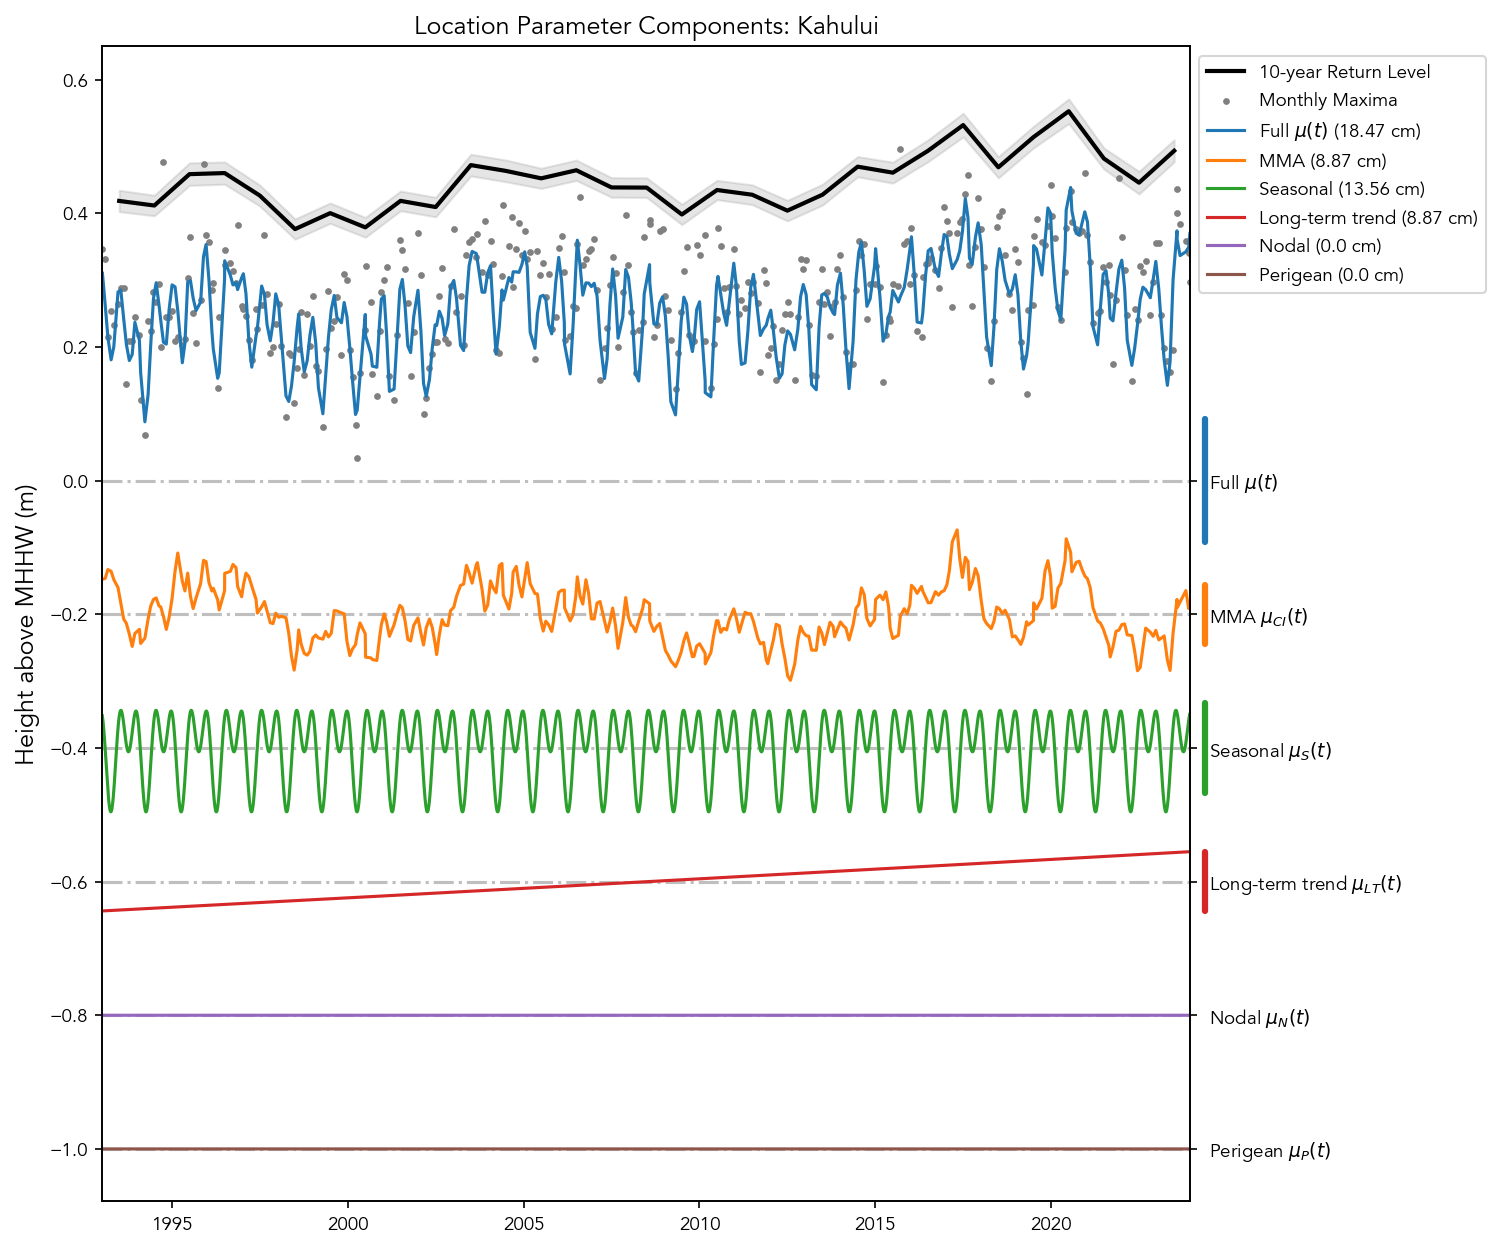

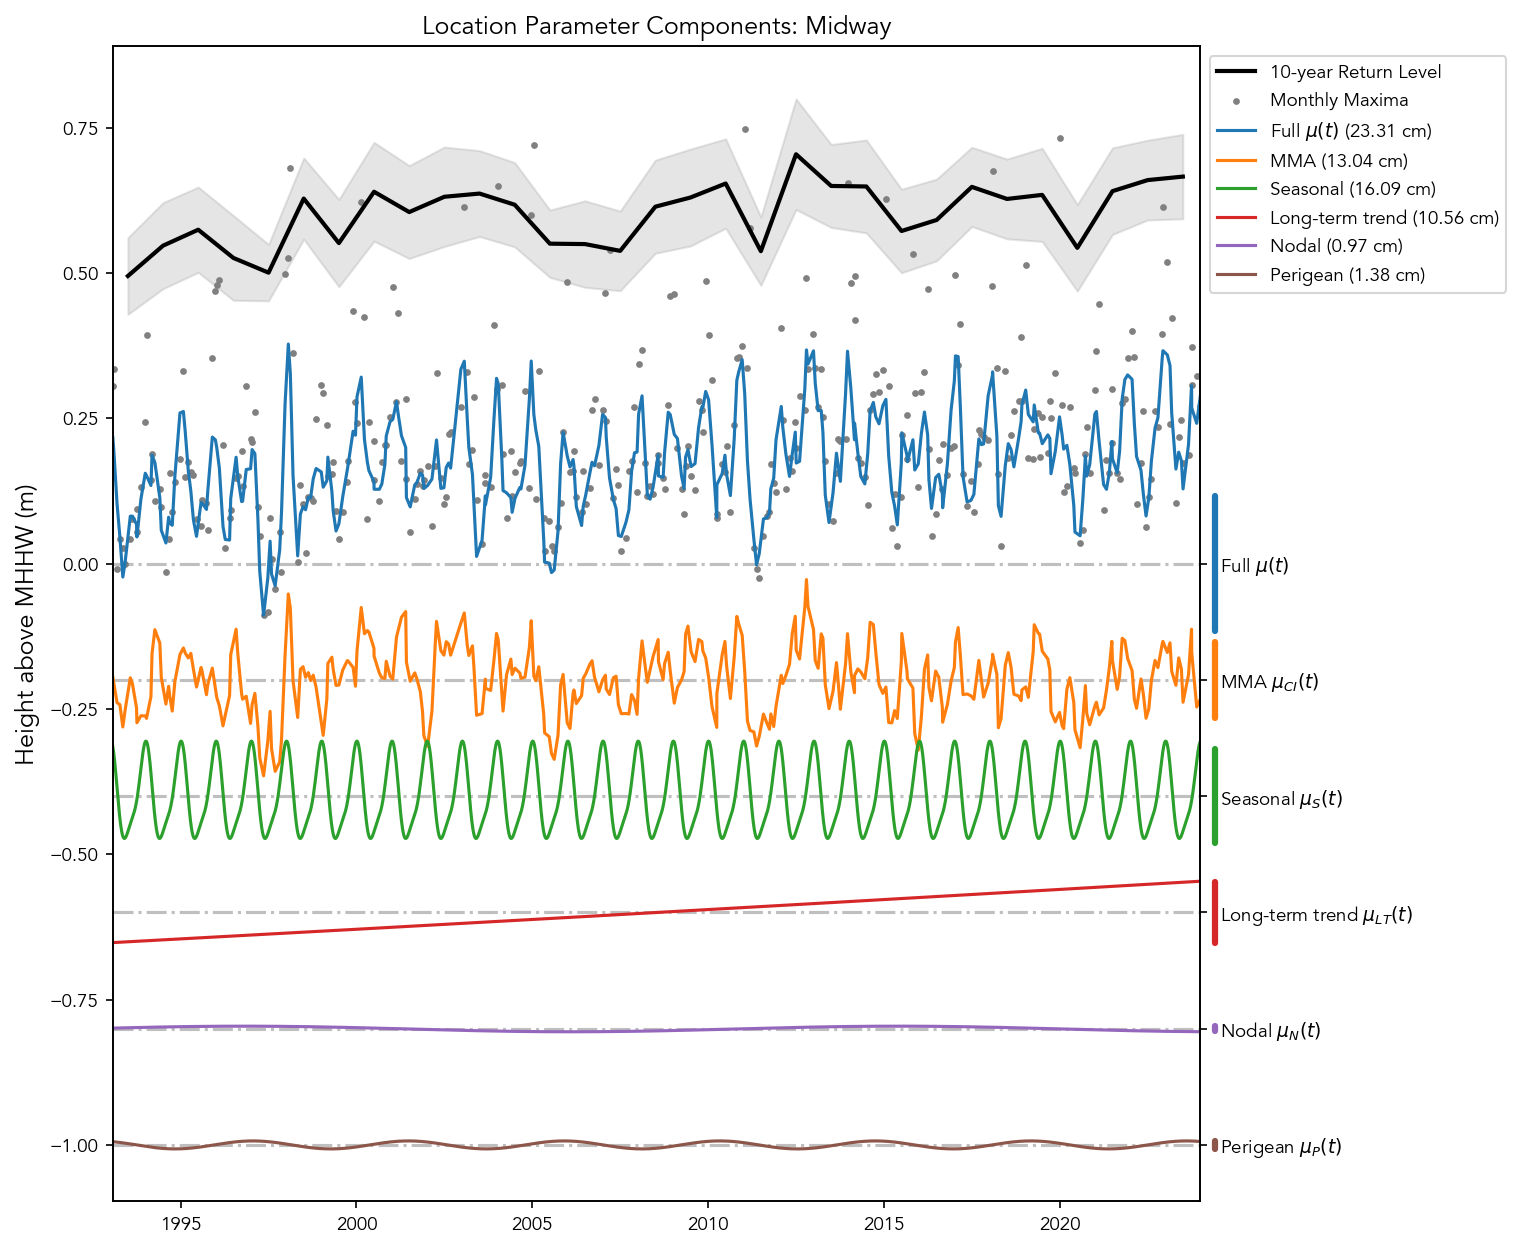

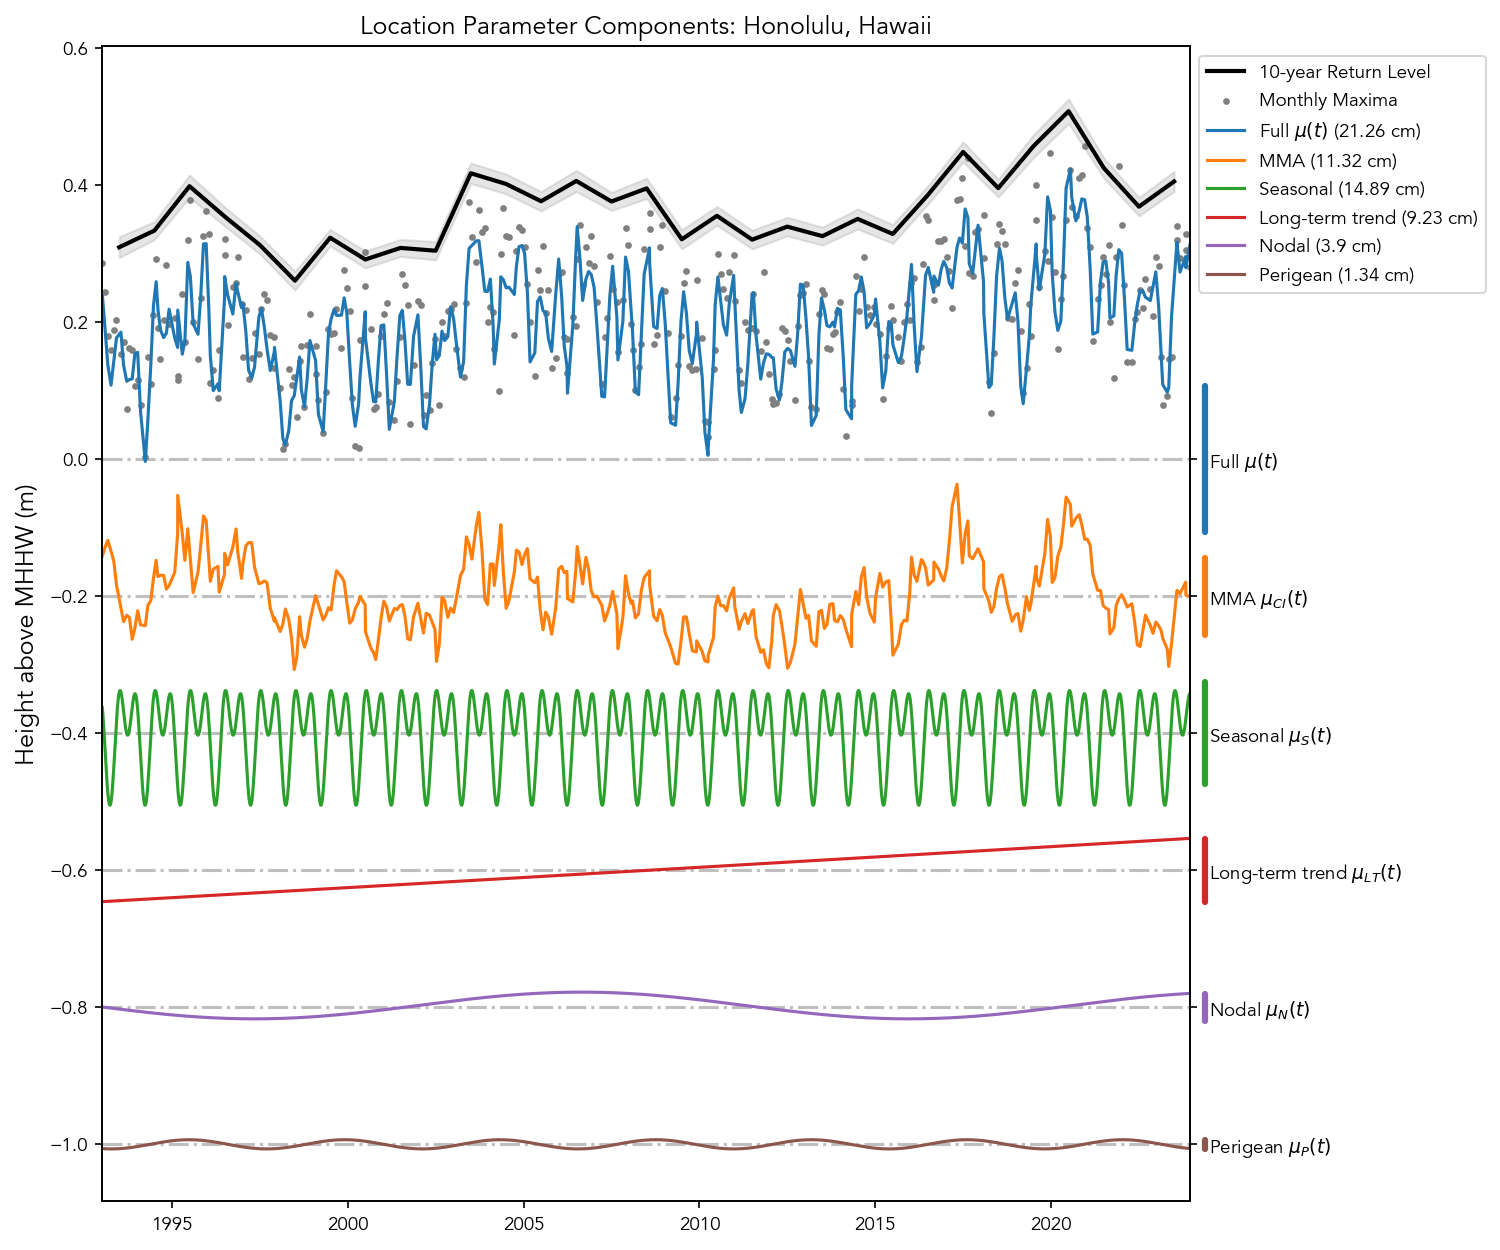

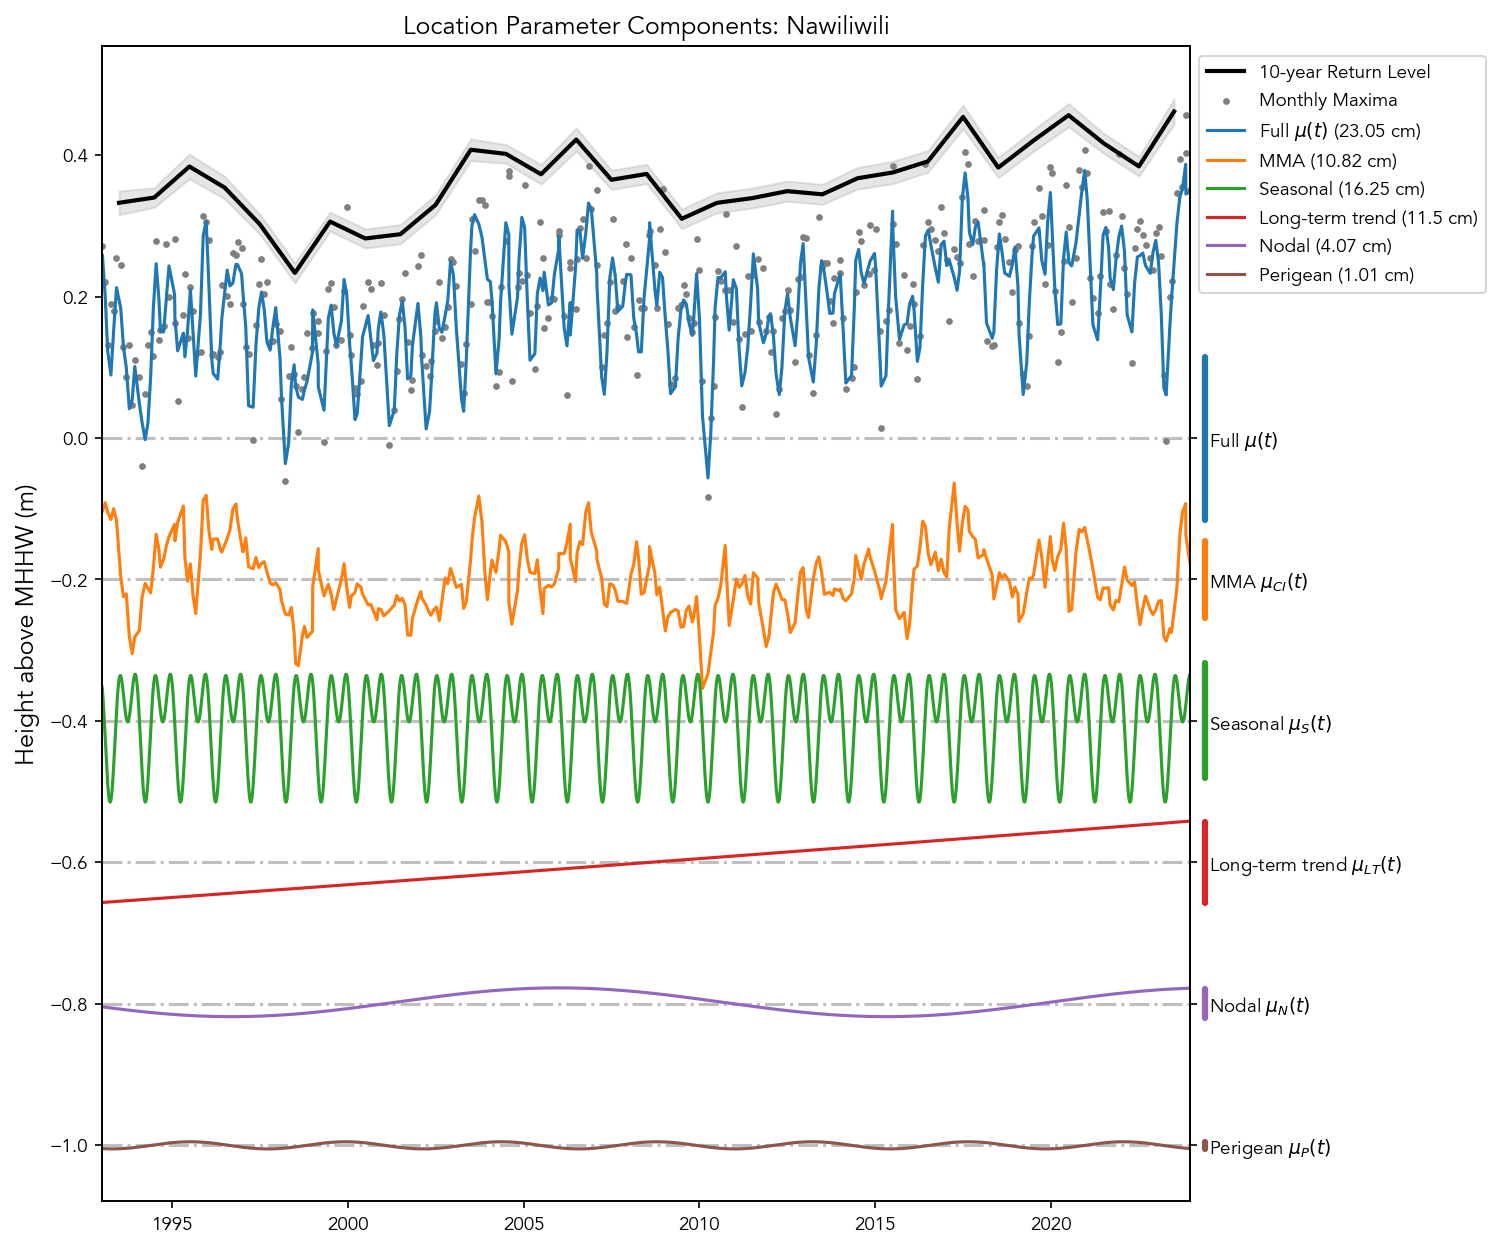

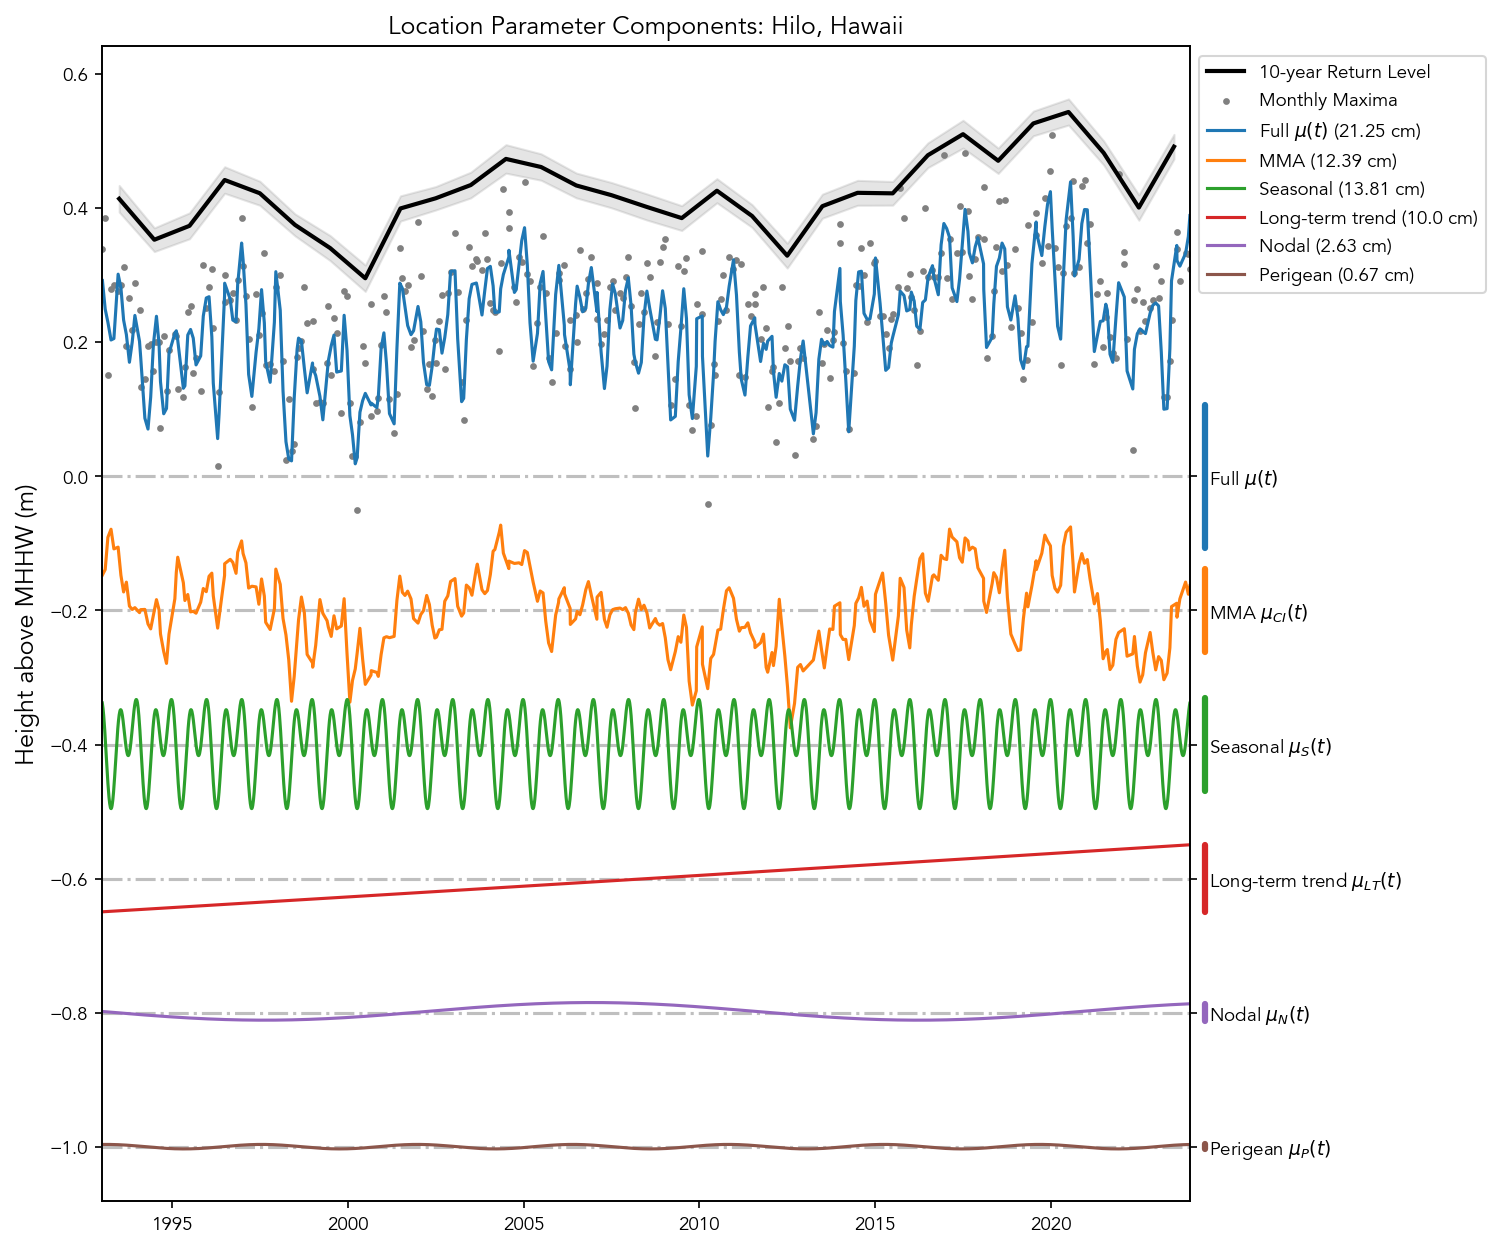

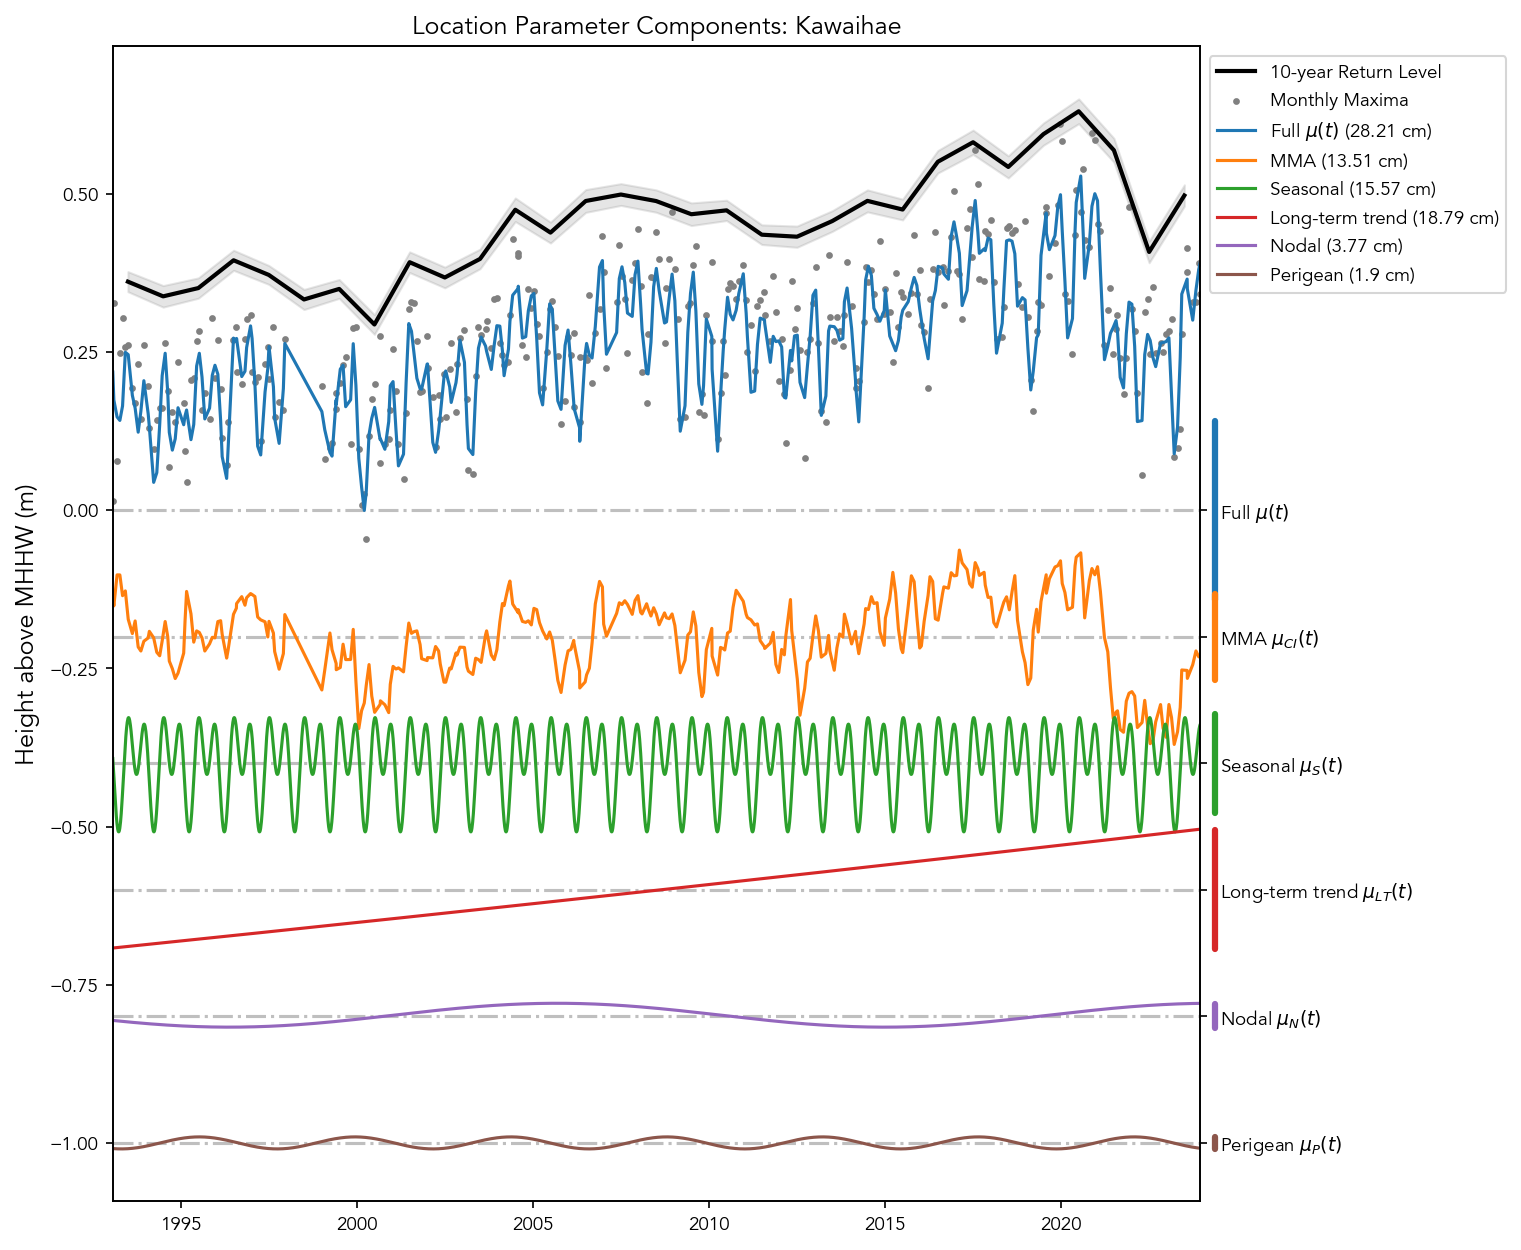

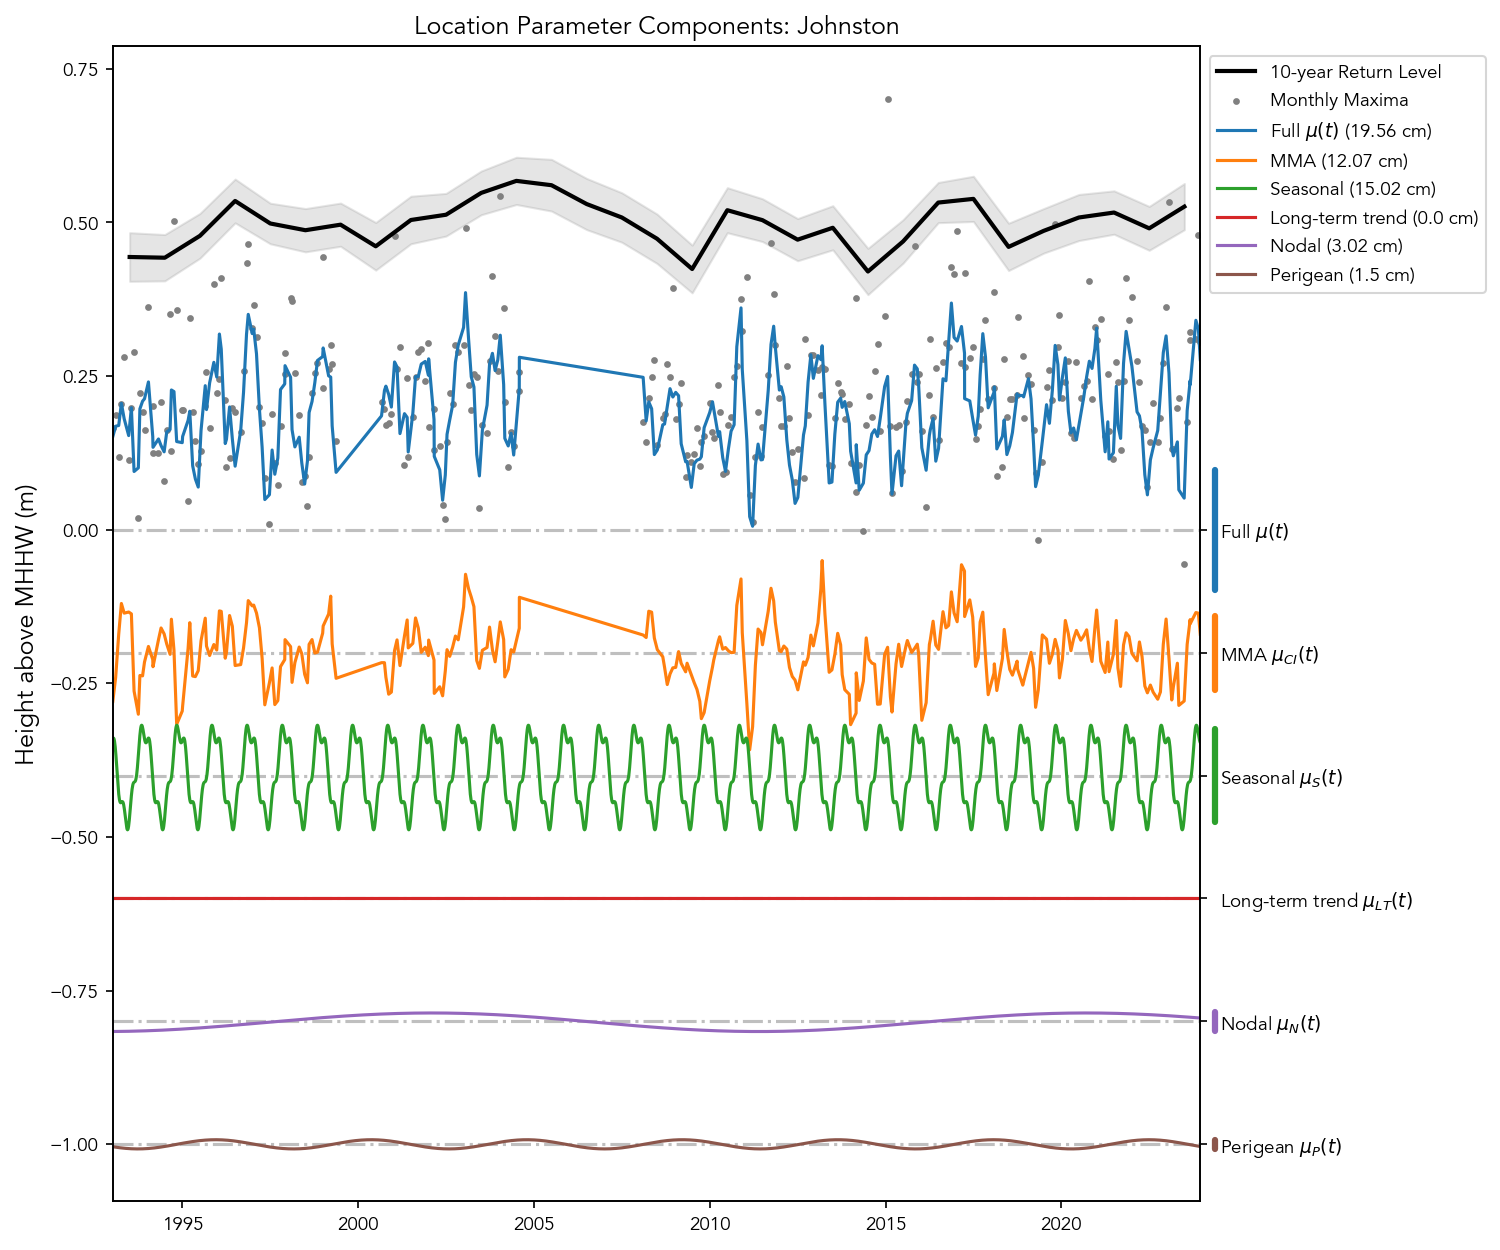

In [14]:
for recordID in recordIDs:

    # read the json file for best model
    jsonpath = Path(dirs['model_output_dir']) / str(recordID) / 'best_params.json'
    with open(jsonpath, 'r') as f:
        output = json.load(f)
        modelInfo = output['modelInfo']
        params = output['w']
        x = output['x']
        
    time = modelInfo['year0'] + pd.Series(modelInfo['t'])

    w = adjust_w_for_plotting(x, params)
    modelType = 'RL_best.nc'
    model = xr.open_dataset(Path(dirs['model_output_dir']) / str(recordID) / modelType)
    fig, amps, ax = make_component_figure(w, modelInfo, model, time)

    #save the figure
    savename = 'LocationComponents_' + model.attrs['station_name'] + 'MMA.png'
    filename = Path(dirs['output_dir']) / savename
    fig.savefig(filename, bbox_inches='tight')

    # save amps to a json file
    amps_json = Path(dirs['model_output_dir']) / str(recordID) / 'location_param_component_amps_MMA.json'
    with open(amps_json, 'w') as f:
        json.dump(amps, f)



Now we'll save the parameter component amplitudes to our model output directory.

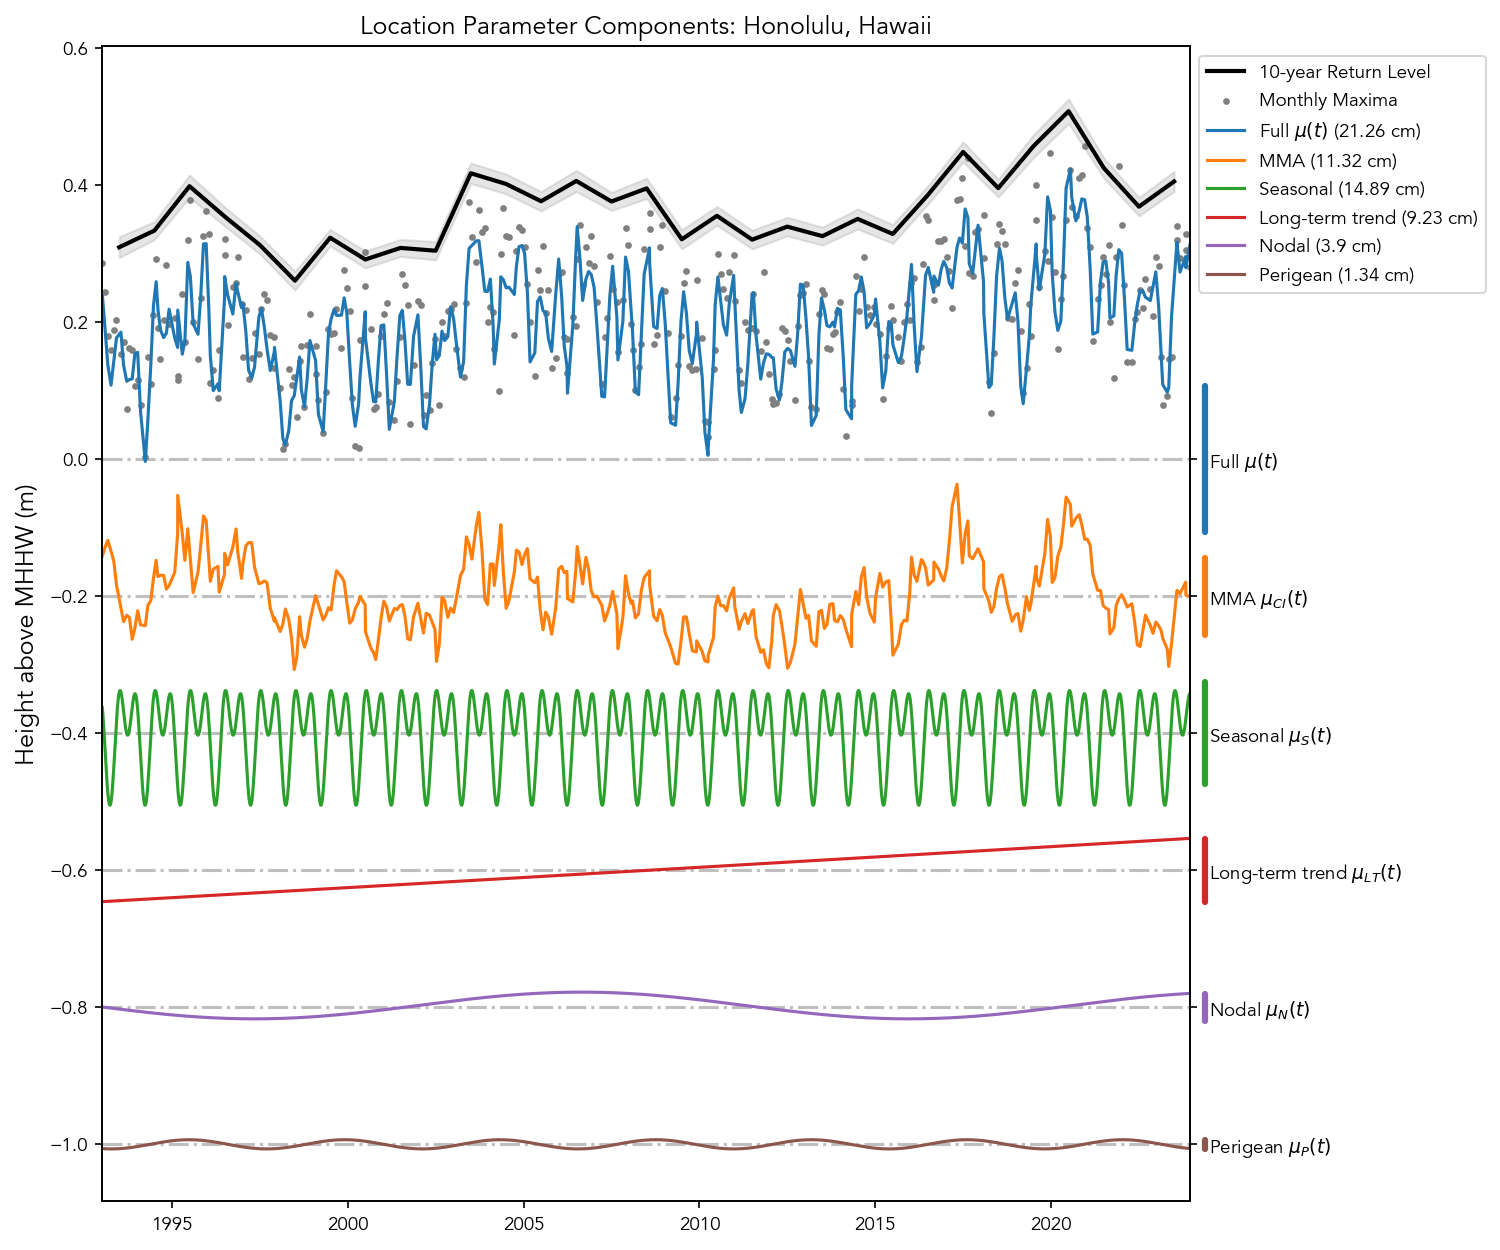

In [15]:
recordID = 57

# read the json file for best model
jsonpath = Path(dirs['model_output_dir']) / str(recordID) / 'best_params.json'
with open(jsonpath, 'r') as f:
        output = json.load(f)
        modelInfo = output['modelInfo']
        params = output['w']
        x = output['x']
        
time = modelInfo['year0'] + pd.Series(modelInfo['t'])

w = adjust_w_for_plotting(x, params)
modelType = 'RL_best.nc'
model = xr.open_dataset(Path(dirs['model_output_dir']) / str(recordID) / modelType)
fig, amps, ax = make_component_figure(w, modelInfo, model, time)

glue("location_components",fig,display=False)
glue("station",model.attrs['station_name'],display=False)


```{glue:figure} location_components
:name: "location_components"

Location parameter components for the {glue:text}`station` tide gauge. 
```

### Plot components by station

The following code can only be run after all gauges have been modeled!

In [16]:
# get all location_parms_component_amp.json files and combine them into one
amps = {}

for recordID in recordIDs:
    amps_json = Path(dirs['model_output_dir']) / str(recordID) / 'location_param_component_amps_MMA.json'
    with open(amps_json, 'r') as f:
        amps[recordID] = json.load(f)


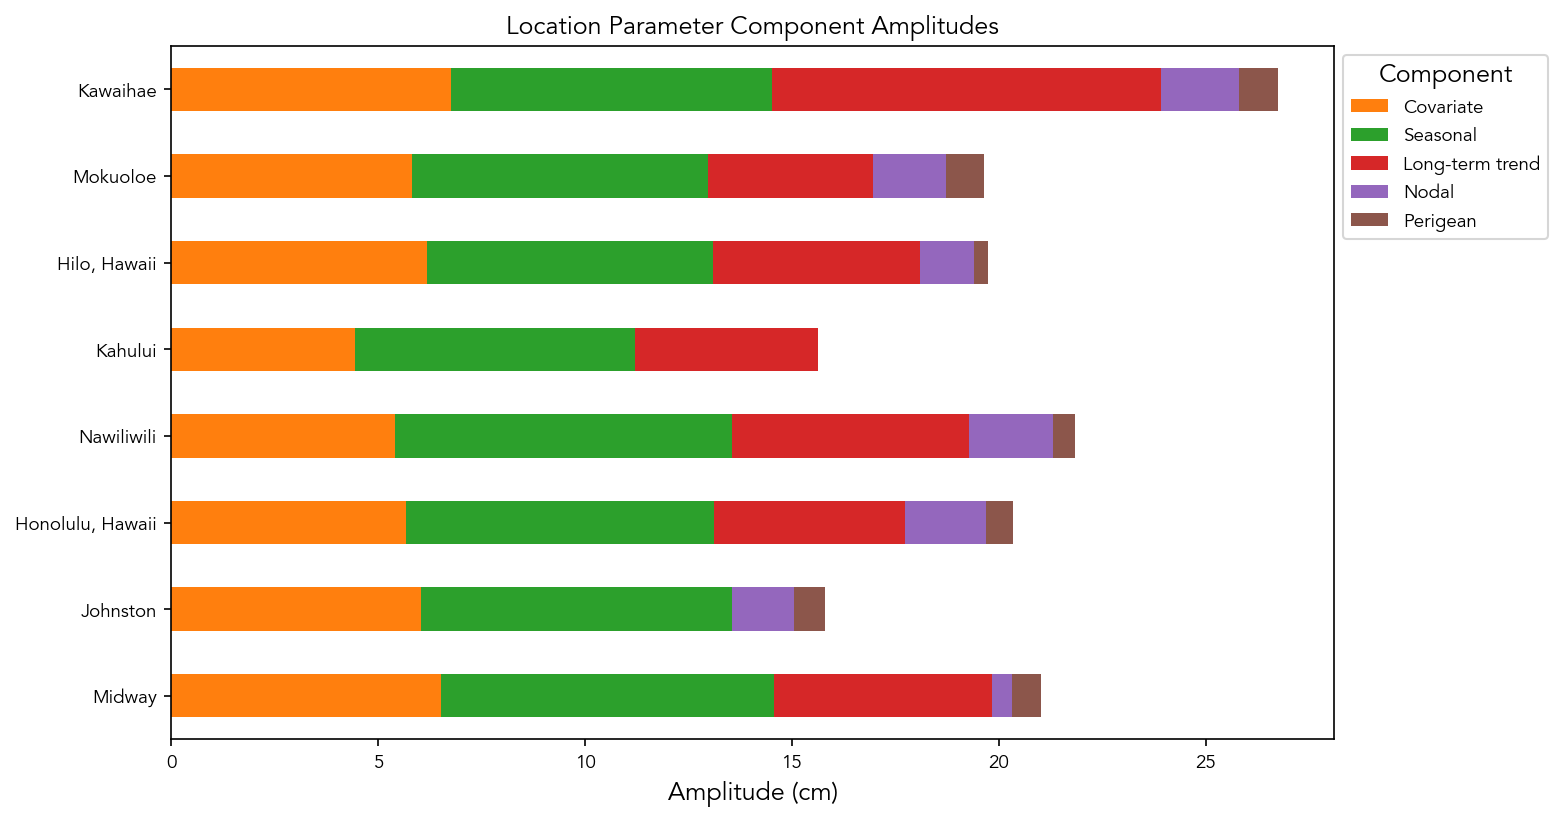

In [17]:
# Plot df as stacked bar chart ignoring the full component
# Turn amps into a dataframe
df = pd.DataFrame(amps).T
df.drop('Full', axis=1,inplace=True)

# Reorder columns to match above plot
df = df[['Covariate','Seasonal', 'Long-term trend',  'Nodal', 'Perigean']]
#rename 'Covariate' to 'BEST (19-month lag)'
# df = df.rename(columns={'Covariate':'BEST (19-month lag)'})
df = df.sort_index()

# conver the data colums to cm and round to 2 decimal places
df = df.apply(lambda x: x*100).round(2)

# add station names to the dataframe
df['Station Name'] = station_names.values()


# Plot the data with amplitudes on the x-axis
df.plot(kind='barh', stacked=True, figsize=(10, 6), color=plt.cm.tab10.colors[1:])
plt.title('Location Parameter Component Amplitudes')
plt.xlabel('Amplitude (cm)')
plt.legend(title='Component', loc='upper left', bbox_to_anchor=(1, 1))

# replace the x-axis with the station names
plt.yticks(np.arange(len(df.index)), df['Station Name']);

# save the plot
savename = Path(dirs['output_dir']) / 'location_param_component_amps_MMA.png'
plt.savefig(savename, bbox_inches='tight')


### Plot a map
Here we'll look at the influence of the climate covariate in the form of a map. First we'll extract the amplitudes of the covariate from every station we've analyzed.


In [18]:
# load rsl data
with xr.open_dataset(dirs['data_dir'] / 'rsl_daily_hawaii.nc') as rsl:
    df = rsl[['lat', 'lon', 'station_name', 'record_id']].to_dataframe().reset_index()
    pass

# Initialize ampCI as a vector of zeros
df['ampCI'] = 0

# Assign ampCI values using the recordID column with vectorization, where possible
df['ampCI'] = df['record_id'].map(lambda rid: amps.get(rid, {}).get('Covariate', 0))

# Initialize modelCI with 'None' as default
df['modelCI'] = 'None'

# Function to get modelCI, with improved error handling
def get_model_ci(record_id):
    fpath = Path(dirs['model_output_dir']) / str(record_id) / 'RL_best.nc'
    try:
        with xr.open_dataset(fpath) as model:
            return model.attrs.get('covariate', 'None')
    except FileNotFoundError:
        print(f'No model found for recordID: {record_id}, skipping...')
        return 'None'
    except Exception as e:
        print(f'Error processing {record_id}: {e}')
        return 'None'

# # Apply the function to the DataFrame (efficient vectorized operation)
# df['modelCI'] = df['record_id'].apply(get_model_ci)
# df['modelCI'] = df['record_id'].map(get_model_ci)


In [19]:
df['modelCI'] = df['record_id'].map(get_model_ci)


No model found for recordID: 14, skipping...
No model found for recordID: 547, skipping...
No model found for recordID: 548, skipping...


In [20]:
df

,record_id,lat,lon,station_name,ampCI,modelCI
0,14,23.867001,193.710007,French Frigate,0.000000,None
1,50,28.216999,182.632996,Midway,0.065185,MMA
2,52,16.750000,190.483002,Johnston,0.060339,MMA
3,57,21.306999,202.132996,"Honolulu, Hawaii",0.056586,MMA
4,58,21.966999,200.649994,Nawiliwili,0.054122,MMA
5,59,20.900000,203.533005,Kahului,0.044344,MMA
6,60,19.733000,204.932999,"Hilo, Hawaii",0.061944,MMA
7,61,21.433001,202.199997,Mokuoloe,0.058106,MMA
8,547,21.322001,201.880005,"Barbers Point, HI",0.000000,None
9,548,20.783001,203.000000,"Kaumalapau, HI",0.000000,None


Next we'll plot up our map. (OR DON'T, the kernel keeps crashing. For now I'm commenting it out.)

In [21]:
# df['ampCI'] = 100*df['ampCI']

# df['ampCI'] = df['ampCI'].round(2)

# # make all ampCI values if zero 0.05
# df['ampCI'] = df['ampCI'].replace(0, 0.3)



# # Separate the "None" entries from the rest of the data
# df_none = df[df['modelCI'] == 'None']  # Entries where modelCI is 'None'
# df_filtered = df[df['modelCI'] != 'None']  # All other entries

In [22]:


# # Use tab10 colormap for colors (excluding 'None')
# cmap = plt.get_cmap('Set1')
# color_dict = {index: cmap(i) for i, index in enumerate(np.unique(df_filtered['modelCI']))}

# # Map the climate indices to numerical values for the colorbar
# index_mapping = {index: i for i, index in enumerate(np.unique(df_filtered['modelCI']))}
# mapped_indices = [index_mapping[ci] for ci in df_filtered['modelCI']]

# # Create a colormap without "None"
# norm = colors.BoundaryNorm(boundaries=np.arange(len(np.unique(df_filtered['modelCI'])) + 1) - 0.5, 
#                                ncolors=len(np.unique(df_filtered['modelCI'])))

# fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# # # Call plot_thin_map_hawaii to create the figure and axis
# plot_thin_map_hawaii(ax)

# # Plot each station with varying color (based on climate index) and size (based on amplitude)
# scatter = ax.scatter(df_filtered['lon'], df_filtered['lat'], 
#                      c=mapped_indices, cmap=cmap, 
#                      norm=norm, s=50 * df_filtered['ampCI'],
#                      edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

# # Plot the "None" stations in gray (fixed color)
# ax.scatter(df_none['lon'], df_none['lat'], 
#            color='gray', s=50 *df_none['ampCI'], 
#            edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree())

# dfInfo = get_stationinfo(dirs['data_dir'])
# dfInfo['record_id'] = dfInfo['record_id']

# #change the font color to black if the station is in the df_filtered
# dfInfo['fontcolor'] = np.where(dfInfo['record_id'].isin(df_filtered['record_id']), 'black', 'gray')

## Add an axes for the colorbar
# cax = fig.add_axes([0.13, 0.21, 0.76, 0.02])  

# # dfInfo
# # Add text labels with adjusted offsets and horizontal alignment
# for i, name in enumerate(dfInfo['station_name']):
#     ax.text(dfInfo['lon'][i] + dfInfo['offsetlon'][i], dfInfo['lat'][i] + dfInfo['offsetlat'][i], name, 
#             ha=dfInfo['ha'][i], fontsize=10, transform=ccrs.PlateCarree(),rotation=0, color = dfInfo['fontcolor'][i])

# # Add a colorbar for the climate index
# cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation='horizontal')
# cbar.set_ticks(np.arange(len(np.unique(df_filtered['modelCI']))))
# cbar.set_ticklabels(np.unique(df_filtered['modelCI']))
# cbar.set_label('Climate Index')


# # Amplitude size legend
# sizes = [50, 100, 150]
# size_labels = ["0.5 cm", "1.5 cm", "3.0 cm"]  
# size_legend_elements = [Line2D([0], [0], marker='o', color='none', label=label, 
#                                markerfacecolor='gray', markersize=size / 10) 
#                         for size, label in zip(sizes, size_labels)]
# ax.legend(handles=size_legend_elements, title="Amplitude Size", loc="lower left")

# # save the figure
# savename = Path(dirs['output_dir']) / 'SL_contributions_map_MMA.png'
# plt.savefig(savename, dpi=300, bbox_inches='tight')

# glue("CI_map",fig,display=False)


```{glue:figure} CI_map
:name: "CI_map"

Map of dominant climate indices in the Hawaiian Islands region. The size of each circle at a given tide gauge represents the amplitude of the climate covariate in the location parameter of nonstationary extremes. ENSO-type climate indices are are well-represented with amplitudes between 1.5-3 cm. Here, the lags for ENSO-type indices in the main Hawaiian Islands are set at 18 months, which aligns well with previous literature (e.g. Long et al 2020). 
```

### Plot sub-annual contributions


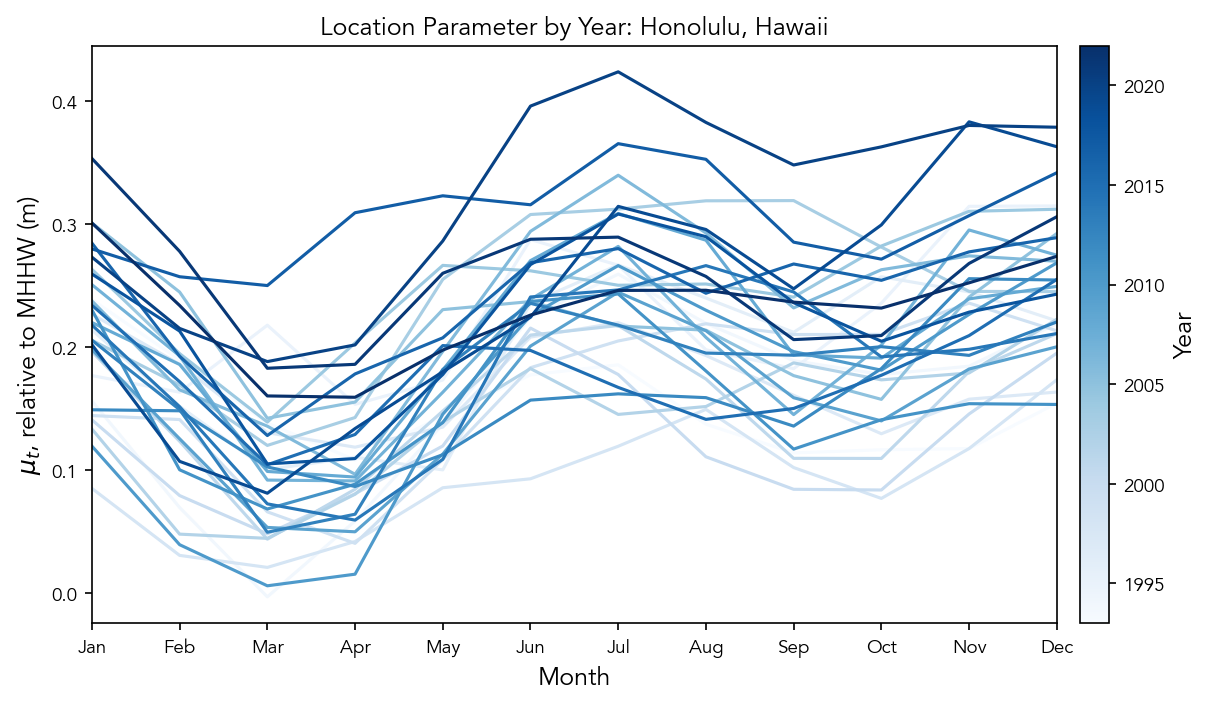

In [25]:
recordID = 57
jsonpath = Path(dirs['model_output_dir']) / str(recordID) / 'best_params.json'
with open(jsonpath, 'r') as f:
    output = json.load(f)
    modelInfo = output['modelInfo']
    params = output['w']
    x = output['x']

w = adjust_w_for_plotting(x, params)    

# params should be a dictionary with the following
paramNames = ['b0','a0','g0','b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'bLT', 'bCI', 'cCI', 'bN1', 'bN2','bP1', 'bP2']
params = {paramNames[i]: w[i] for i in range(len(paramNames))}

t = np.array(modelInfo['t'])
ci = np.array(modelInfo['covariate'])
# Convert t to years
tyears = t + modelInfo['year0']

# Constants
api = np.pi # pi
ak = 2 * api # 2pi
ak18 = 2 * api / 18.61  # 18.61-year nodal cycle
ak4 = 2 * api / 4.425  # 4.425-year perigean cycle

mut = (params['b0'] * np.exp(params['bLT'] * t) +
        params['b1'] * np.cos(ak * t) + params['b2'] * np.sin(ak * t) +
        params['b3'] * np.cos(2 * ak * t) + params['b4'] * np.sin(2 * ak * t) +
        params['b5'] * np.cos(4 * ak * t) + params['b6'] * np.sin(4 * ak * t) +
        params['bN1'] * np.cos(ak18 * t) + params['bN2'] * np.sin(ak18 * t) +
        params['bP1'] * np.cos(ak4 * t) + params['bP2'] * np.sin(ak4 * t) +
        params['bCI'] * ci)

mut = mut - modelInfo['STNDtoMHHW']


tfrac = t-np.floor(t)

import calendar
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

t00 = np.arange(1993,2023)
# make colormap the same length as t00
cmap = plt.cm.Blues(np.linspace(0,1,len(t00)))
# plt.plot(tyears(np.floor(tyears)==t00),mut[np.floor(tyears)==t00])
for t0 in t00:
    inYear = np.floor(tyears).astype(int) == t0
    color_index = np.where(t00 == t0)[0][0]  # Find the index of t0 in t00
    plt.plot(np.arange(0, 1, 1/12), mut[inYear], label=str(t0), color=cmap[color_index])

# xlim([0,1])
# set the xlimits to 0 and 1
plt.xlim(0,1-1/12)
# set the xticks to be the months
plt.xticks(np.arange(0, 1, 1/12), [calendar.month_abbr[i] for i in range(1, 13)])
plt.xlabel('Month')
plt.ylabel('$\mu_t$, relative to MHHW (m)')
plt.title('Location Parameter by Year: ' + modelInfo['station_name'])


sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=t00.min(), vmax=t00.max()))
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', pad=0.02)
cbar.set_label('Year')

glue("location_by_year",fig,display=False)
savename = 'location_by_year_' + modelInfo['station_name'] + 'MMA.png'
plt.savefig(output_dir / savename, dpi=300, bbox_inches='tight')

#glue the CI name
glue("CI_name",modelInfo['covariateName'],display=False)
glue("station",modelInfo['station_name'],display=False)

# get lag for covariateName
# df_cvteLocation = pd.read_json(Path(dirs['model_output_dir']) / str(recordID) / 'cvte_location_params_MMA.json')

# CI_lag = df_cvteLocation[df_cvteLocation['Climate Index'] == modelInfo['covariateName']]['lag'].values[0]
# glue("CI_lag",CI_lag,display=False)

```{glue:figure} location_by_year
:name: "location_by_year"

This plot shows the changes in the location parameter (with covariate included) from 1993 through 2023 for the non-stationary GEV model at {glue:text}`station`. This particular calculation uses the {glue:text}`CI_name` climate index at a {glue:text}`CI_lag`-month lag. While there is a steady trend (background sea level rise), this is also affected by the covariate and nodal influences.
```


---

### Citations

```{bibliography}
:style: plain
:filter: docname in docnames
```